[\[GitHub\] Jupyter Notebook](https://github.com/sslastochkin/mcab/blob/main/docs/guide/09_compare_setups.ipynb)

# Comparing Setups and Picking the Best  
  
You have learned about Type I error control (Section 3), power and MDE (Section 6), and power-boosting methods (Section 8). The natural next question is: **given several candidate experiment setups, which one should you actually use?**

A "setup" (or *designer*) is any combination of:  
  
- a **metric** (ARPU, conversion rate, average bill, …)
- a **variance-reduction method** (none, CUPED, post-stratification, CUPAC, …)
- a **statistical test** (t-test, Mann–Whitney U, permutation, …)

The `BenchMarker` class lets you evaluate all candidates **side-by-side under identical simulation conditions** so the comparison is fair.

!!! warning "The golden rule"
    Never choose a setup based on power alone. A test can appear more powerful simply because it **inflates the Type I error rate**. Always verify Type I error control first — only then compare power.

This guide walks through two concrete scenarios:  
  
1. **Comparing variance-reduction methods** applied to the same metric (ARPU)
2. **Comparing different metrics** (ARPU vs. Average Bill with and without linearisation)

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

from mcab import (
    RandomData,
    AaDataIid,
    AaDataRatio,
    DesignerIid,
    DesignerRatioLin,
    CUPED,
    PostStratification,
    CUPAC,
    BenchMarker,
)


## Part 1: Comparing Variance-Reduction Methods

We work with synthetic ARPU-like data: exponential revenue distribution with a correlated pre-experiment covariate (for CUPED) and decile-based strata (for post-stratification).


In [2]:
rng = np.random.default_rng(42)
N = 10_000

# Target metric: ARPU — right-skewed, typical for revenue
arpu = rng.exponential(scale=1_000.0, size=N)

# Pre-experiment covariate: noisy historical version of the metric (strong correlation)
noise = rng.normal(0, arpu.std(), size=N)
covariate_pre = pd.Series(arpu + noise, name='pre_arpu')

# Decile-based strata for post-stratification (OHE, drop first to avoid collinearity)
deciles = pd.qcut(covariate_pre, q=10, labels=False).values.reshape(-1, 1)
strata_ohe = pd.DataFrame(
    OneHotEncoder(sparse_output=False, drop='first').fit_transform(deciles)
)

r = np.corrcoef(arpu, covariate_pre)[0, 1]
print(f"N = {N:,} users")
print(f"ARPU  : mean={arpu.mean():.1f},  std={arpu.std():.1f}")
print(f"Covariate correlation with ARPU: r = {r:.3f}")


N = 10,000 users
ARPU  : mean=988.7,  std=992.5
Covariate correlation with ARPU: r = 0.715


## Candidate Setups

We define five `DesignerIid` objects — four reasonable candidates and one **deliberately flawed** method to demonstrate the Type I error gate.

| Name | Variance reduction | Test |
|---|---|---|
| `d_baseline` | — | two-sample t-test |
| `d_cuped` | CUPED | two-sample t-test |
| `d_poststrat` | Post-stratification | two-sample t-test |
| `d_mannwhitney` | — | Mann–Whitney U |
| `d_naive_1samp` ⚠️ | — | **one-sample** t-test ← common bug |

**Why does `d_naive_1samp` fail?**  
It uses `ttest_1samp(test, popmean=mean(control))`, treating the control mean as a **known population constant** rather than a random variable. This removes the control group's variance from the denominator, making the t-statistic ≈ √2 larger than correct — enough to push the false-positive rate from 5 % to ~17 %.


In [3]:
from sklearn.linear_model import LinearRegression, Ridge

# p-value functions
pval_ttest = lambda t, c: stats.ttest_ind(t, c).pvalue
pval_mwu   = lambda t, c: stats.mannwhitneyu(t, c, alternative='two-sided').pvalue

# ⚠️ Deliberately wrong: treats the random control mean as a fixed constant
pval_1samp = lambda t, c: stats.ttest_1samp(t, popmean=np.mean(c)).pvalue

def _ohe_factory(categories):
    """OHE factory: named function so joblib can pickle it across workers."""
    return OneHotEncoder(
        categories=categories,
        drop='first',
        sparse_output=False,
        handle_unknown='ignore',
    )

def cuped_transform(X, y):
    return y - CUPED().fit_predict(X, y)

def pstrat_transform(X, y):
    return y - PostStratification().fit_predict(X, y)

def cupac_ols_transform(X, y):
    return y - CUPAC(LinearRegression(fit_intercept=True, copy_X=False)).fit_predict(
        X, y,
        cat_cols=['strat'],
        cat_encoder=_ohe_factory,   # ← named function, not a nested lambda
    )

# AaData containers (embed transformers here)
aa_baseline  = AaDataIid(arpu)
aa_cuped     = AaDataIid(arpu, transformer=cuped_transform,  covariates=covariate_pre)
aa_poststrat = AaDataIid(arpu, transformer=pstrat_transform, covariates=strata_ohe)

# Designers
d_baseline    = DesignerIid(aa_baseline,  name='Baseline (t-test)',           pval_func=pval_ttest)
d_cuped       = DesignerIid(aa_cuped,     name='CUPED (t-test)',               pval_func=pval_ttest)
d_poststrat   = DesignerIid(aa_poststrat, name='PostStrat (t-test)',           pval_func=pval_ttest)
d_mannwhitney = DesignerIid(aa_baseline,  name='MannWhitney U',                pval_func=pval_mwu)
d_naive_1samp = DesignerIid(aa_baseline,  name='Naive 1-sample t \u26a0\ufe0f', pval_func=pval_1samp)

all_designers = [d_baseline, d_cuped, d_poststrat, d_mannwhitney, d_naive_1samp]

bm = BenchMarker(all_designers, alpha=0.05, beta=0.20)
print(f"BenchMarker ready with {len(all_designers)} designers.")

BenchMarker ready with 5 designers.


## Step 0: Variance Sanity Check

Before running any simulations, `compare_variance()` computes the **effective variance** of each designer's metric *after* applying its transformer to the full dataset. This is a cheap analytical check — no simulations required.

- 🔽 Lower variance → better sensitivity potential  
- ⚠️ Variance alone is **not** sufficient — a miscalibrated test can look low-variance while still inflating FTE

Use this as a quick orientation before committing to expensive simulations.


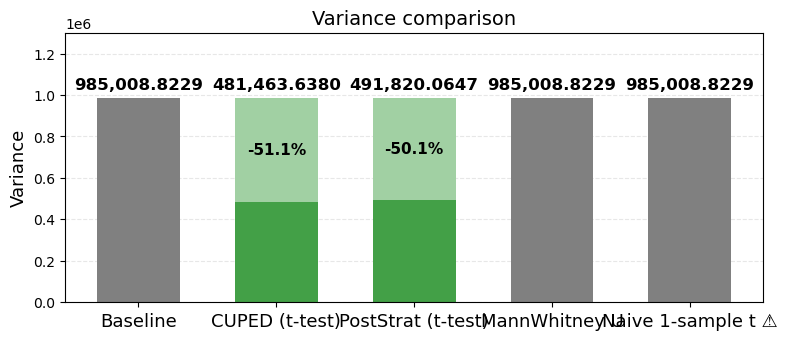

In [4]:
ax, var_results = bm.compare_variance()

## Step 1 (Gate): Type I Error Check

The A/A benchmark runs **thousands of simulations with no injected effect** and measures how often each designer incorrectly rejects H₀. P-values should follow a uniform U[0,1] distribution under the null.

**Acceptance criterion:**  
A designer passes if the 95 % Wilson CI for its observed FTE is consistent with the nominal α = 0.05.  
Formally: **fail** if the CI lower bound strictly exceeds α (statistically significant inflation).  
Any failing designer is **excluded from all subsequent analysis**.  
  
!!! warning "Color scheme"
    `Designer`s have color scheme to estimate validity of simulations.  
    But here we dont call `Designer` – we call BenchMarker.  
    It doesn't have this validation logic and use colors just as labels.  

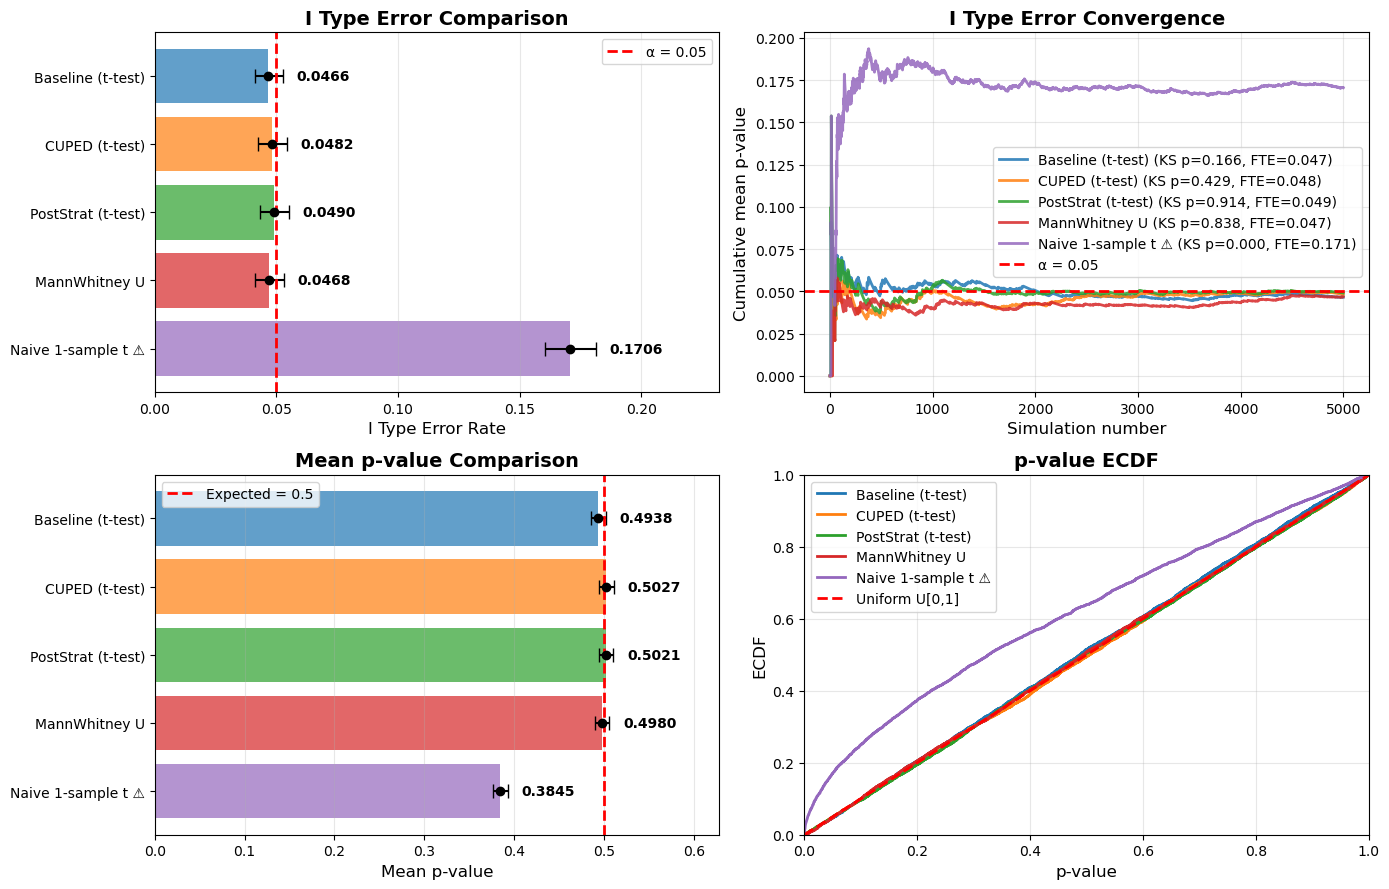

In [5]:
aa_pvalues, aa_stats = bm.aa_benchmark(
    n_sims=5_000,
    plot_hists=True,
    n_jobs=-1,
    verbose=False
)

### Reading the Gate Results

The plot confirms:  
  
- **Baseline**, **CUPED**, **PostStrat**, and **Mann–Whitney** all have FTE within the acceptable band ✅  
- **Naive 1-sample t ⚠️** has FTE ≈ 17 % — flagged red, CI lower bound >> 0.05 → **eliminated** ❌

This is the key insight: a method with inflated FTE is not "more powerful" — it is **miscalibrated**. Its rejections in production cannot be trusted.


In [6]:
shortlist_designers = []
shortlist_labels    = []

print(f"{'Designer':<35}  {'FTE':>6}  {'CI lower':>9}  {'CI upper':>9}  Status")
print("-" * 75)

for designer, name, s in zip(bm.designers, bm.labels, aa_stats):
    fte        = s['mean_p_ft']
    ci_lo      = s['mean_p_ft_left']
    ci_hi      = s['mean_p_ft_right']
    # Fail criterion: CI lower bound statistically exceeds alpha
    passes     = ci_lo <= bm.alpha
    status     = "✅ pass" if passes else "❌ fail (excluded)"
    print(f"{name:<35}  {fte:>6.3f}  {ci_lo:>9.3f}  {ci_hi:>9.3f}  {status}")
    if passes:
        shortlist_designers.append(designer)
        shortlist_labels.append(name)

print(f"\nShortlist: {shortlist_labels}")

Designer                                FTE   CI lower   CI upper  Status
---------------------------------------------------------------------------
Baseline (t-test)                     0.047      0.041      0.053  ✅ pass
CUPED (t-test)                        0.048      0.043      0.054  ✅ pass
PostStrat (t-test)                    0.049      0.043      0.055  ✅ pass
MannWhitney U                         0.047      0.041      0.053  ✅ pass
Naive 1-sample t ⚠️                   0.171      0.160      0.181  ❌ fail (excluded)

Shortlist: ['Baseline (t-test)', 'CUPED (t-test)', 'PostStrat (t-test)', 'MannWhitney U']


## Step 2: Power Race Among Survivors

We now compare **statistical power** across all shortlisted designers.

**Fair comparison rule:** every designer receives the **same relative effect** (here, +5 % on ARPU). Because the injected effect is identical, any difference in power reflects genuine sensitivity gain — not a head start from a larger effect.

The designer with the **highest power at the researcher's target effect** wins.  
Power curves confirm that the winner dominates across the full range of effects, not just at the chosen benchmark point.


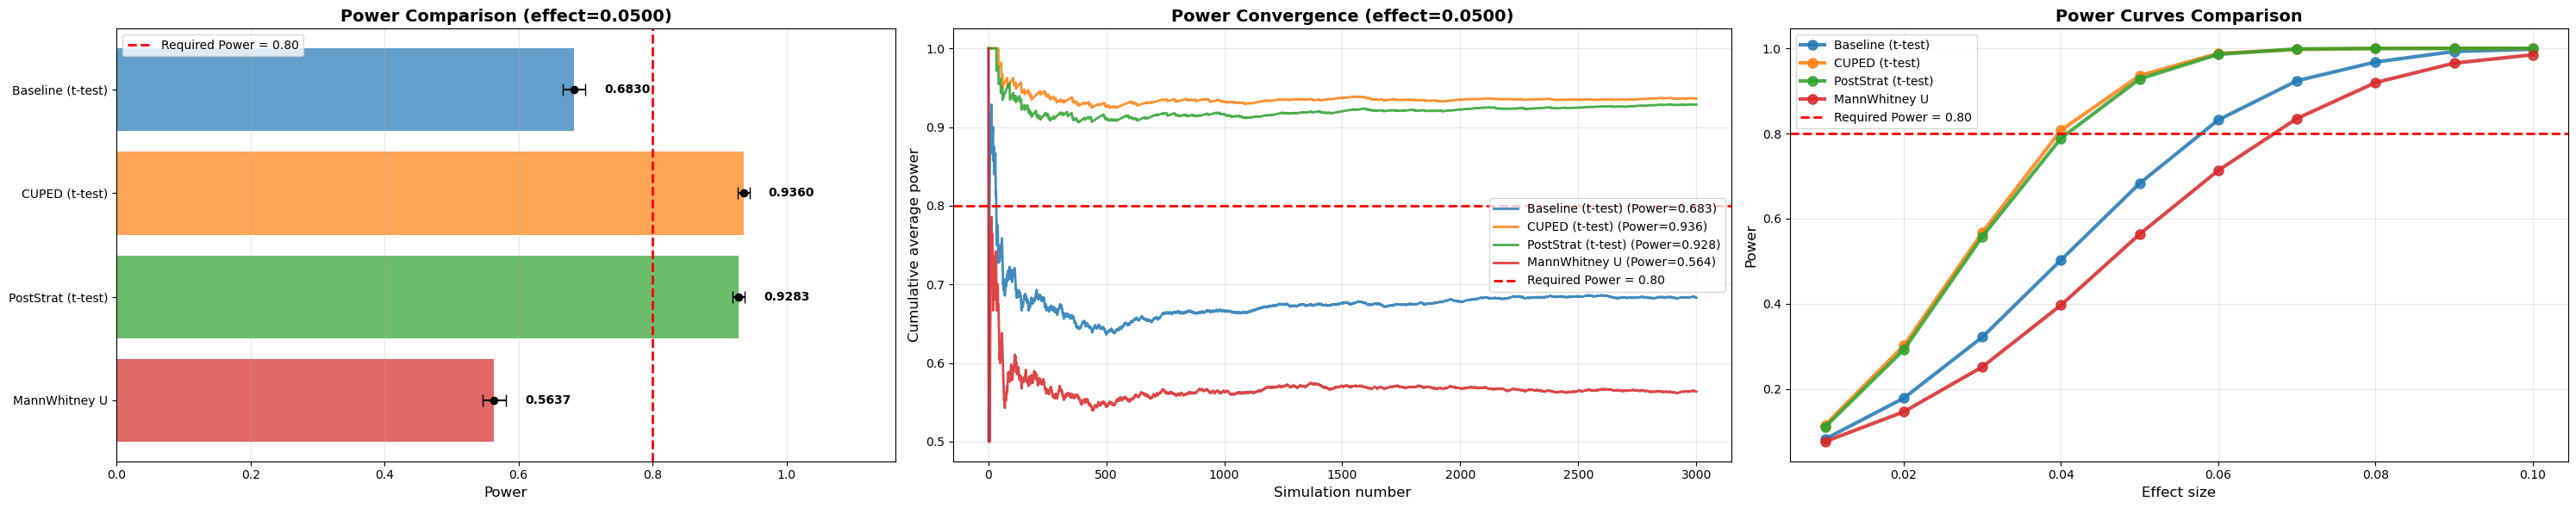

In [7]:
bm_short = BenchMarker(shortlist_designers, alpha=0.05, beta=0.20)

bar_stats, power_curves = bm_short.ab_benchmark(
    bar_effect=0.05,
    power_curve_effects=list(np.linspace(0.01, 0.10, 10)),
    n_sims=3_000,
    n_jobs=-1,
    verbose=False
)

### Interpreting the Power Results

From the charts:  
  
- **CUPED** and **PostStratification** achieve the highest power — variance reduction directly translates to shorter experiments  
- **Mann–Whitney** is on par with the plain t-test here; it gains no variance reduction but remains a valid non-parametric alternative  
- **Baseline** is the floor

**Winner: CUPED (t-test)** — highest power, simple, and interpretable.

!!! tip "Power curves tell the full story"
    A single-effect bar chart can mislead if the true effect in production differs from the benchmark. The power curve confirms CUPED dominates across the entire range of plausible effects.


## Step 3 (Optional): Directional Analysis

Before deploying a new method (here, CUPED) it is prudent to verify it **agrees with the baseline on effect direction** across many simulated experiments.  
*Sign disagreements* mean the two methods would reach opposite conclusions about whether to ship the feature — a serious operational risk.

Key outputs:  
  
- **Sign agreement** — fraction of simulations where both methods agree on direction (aim for ≥ 0.95)  
- **R²** — variance of CUPED estimates explained by baseline estimates (aim for ≥ 0.90)  
- **Bland–Altman plot** — detects systematic bias or proportional divergence

This step is especially valuable when adopting an untested method in production for the first time.


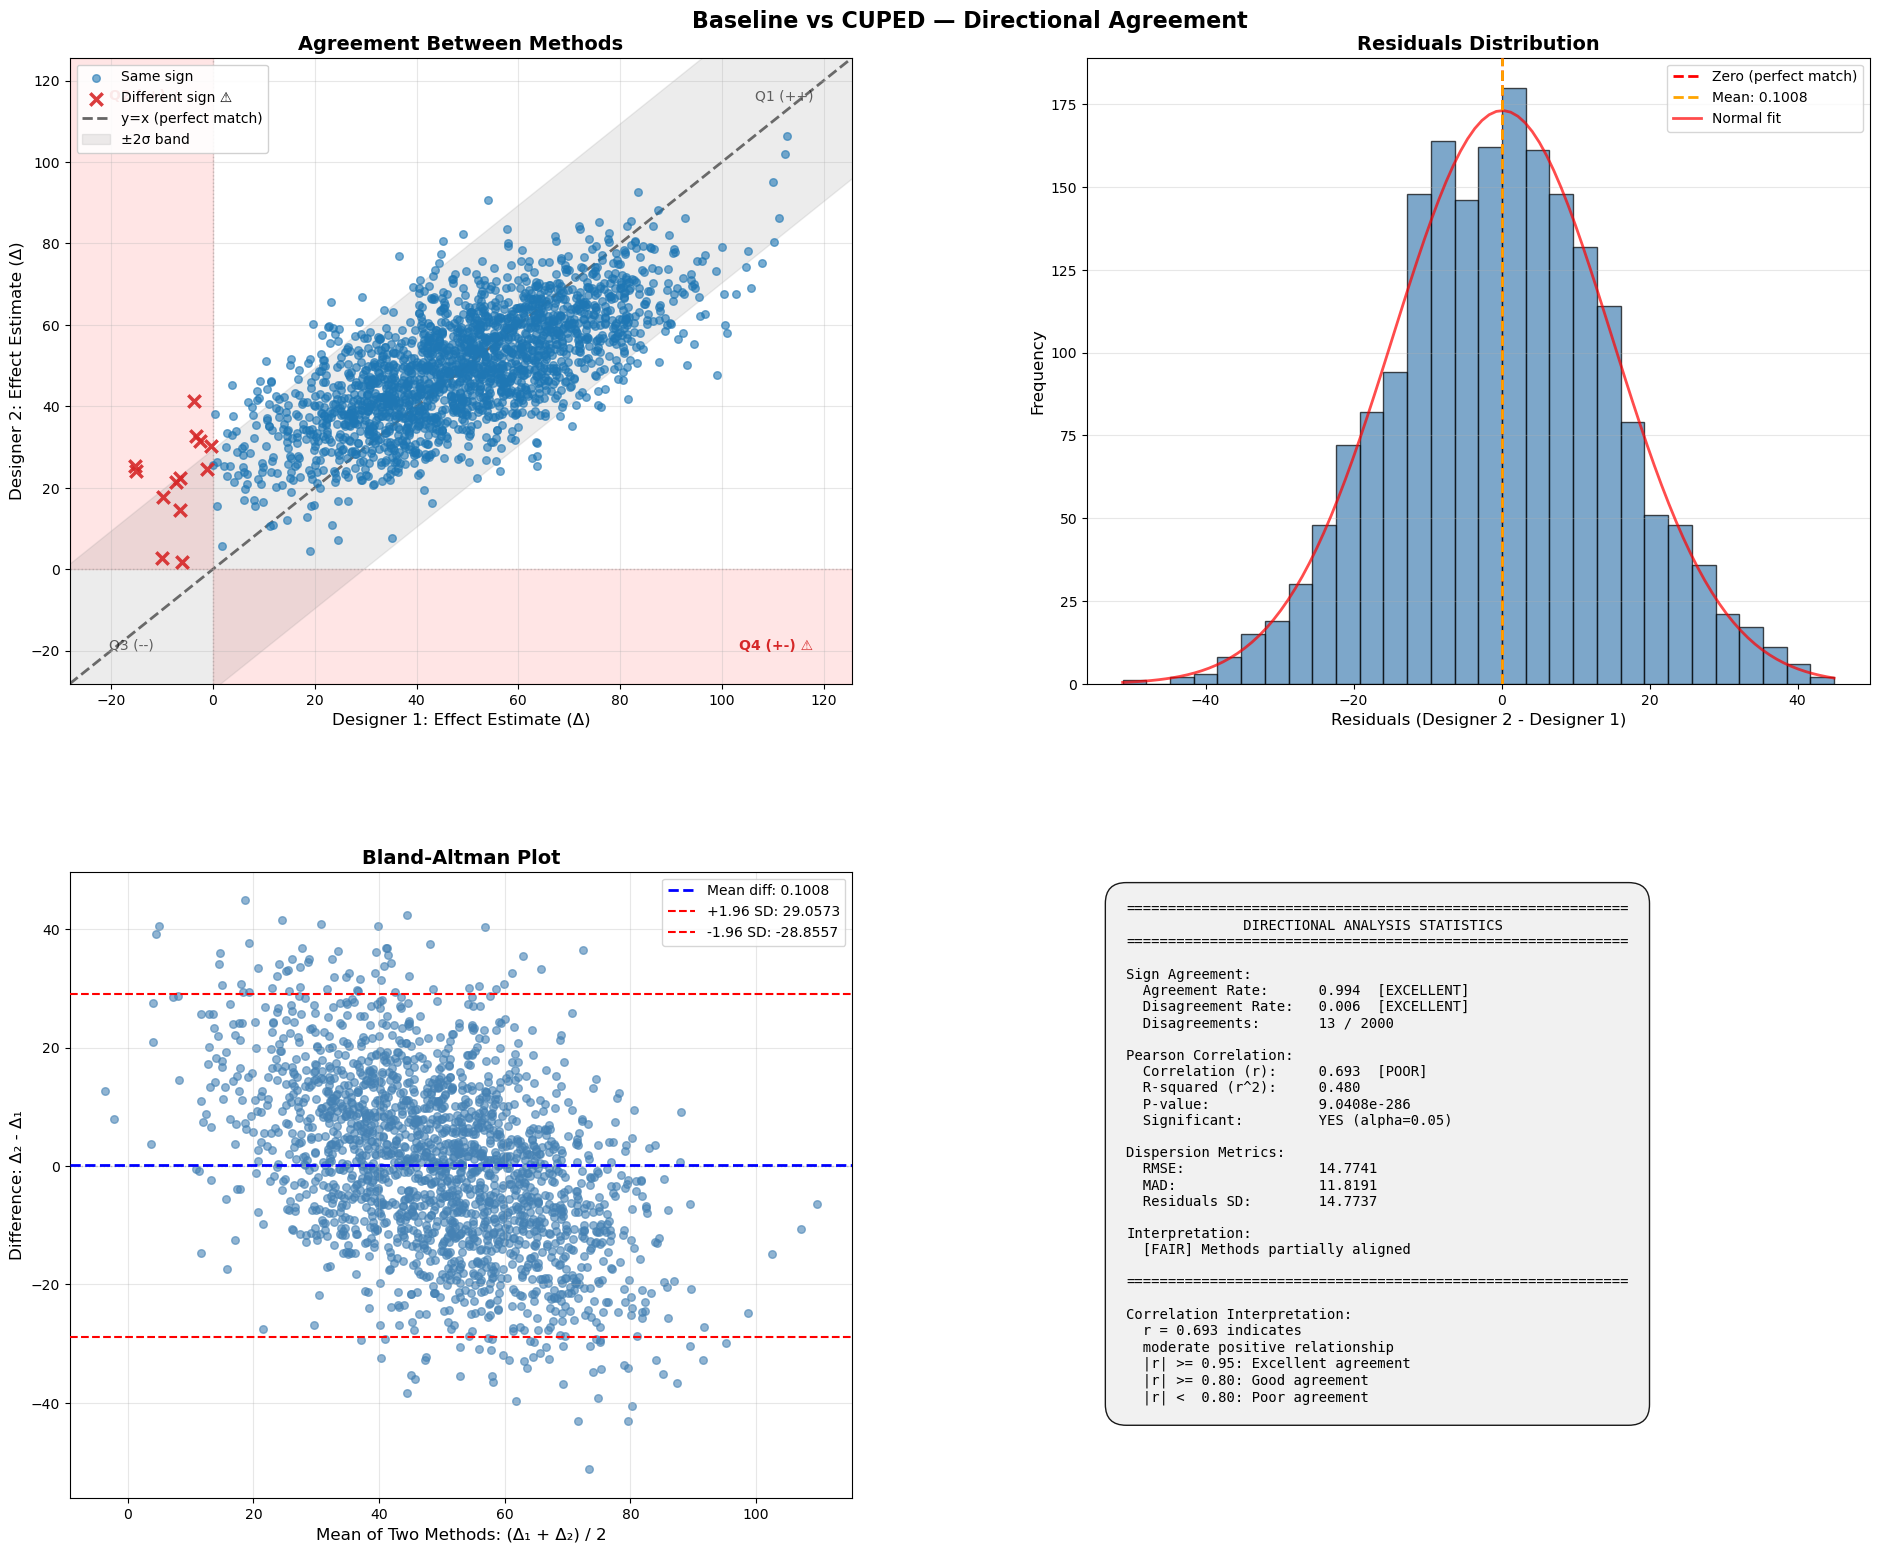

Sign agreement : 0.994
R²             : 0.480
Disagreements  : 13 / 2000


In [8]:
da_results = bm.directional_analysis(
    designer1=d_baseline,
    designer2=d_cuped,
    effect=0.05,
    n_sims=2_000,
    suptitle='Baseline vs CUPED — Directional Agreement',
    verbose=False
)

print(f"Sign agreement : {da_results['sign_agreement']:.3f}")
print(f"R²             : {da_results['r_squared']:.3f}")
print(f"Disagreements  : {len(da_results['disagreement_indices'])} / {2000}")


## Part 2: Comparing Different Metrics

So far we compared different *methods* applied to the **same metric** (ARPU). Now we compare **different metrics** for the same business outcome — specifically, how to measure "average spend" per user.

Two natural choices:  
  
1. **ARPU** — one value per user, simple IID metric
2. **Average Bill** — total revenue / total purchases (a ratio metric: meaningful only at the aggregate level)

Ratio metrics require special treatment because the per-unit value `revenue_i / purchases_i` is a **biased estimator** of the true aggregate ratio `E[R]/E[D]`, and its sampling variance is not correctly captured by a plain t-test. The **linearisation** (`DesignerRatioLin`) solves this by transforming each user's data to `L_i = R_i − θ * D_i` where `θ = E[R]/E[D]` estimated from the control group.

We compare three designers:

| Designer | Metric | Method |
|---|---|---|
| `dm_arpu` | ARPU | IID t-test |
| `dm_avgbill_lin` | Avg Bill | **Linearised** — principled ✅ |
  

In [9]:
rdata2 = RandomData(seed=123)

# Ratio metric data: revenue (exponential) and purchases (Poisson+1)
revenue, purchases = rdata2.ratio_data_avg_bill(size=10_000, scale=1_500.0, lam=2.0)

# ARPU: use the same revenue stream as a plain IID metric
arpu2 = revenue.copy()

avgbill  = revenue.sum() / purchases.sum()

print(f"Revenue   : mean={revenue.mean():.1f},  std={revenue.std():.1f}")
print(f"Purchases : mean={purchases.mean():.2f}, std={purchases.std():.2f}")
print(f"Avg bill  : {avgbill:.2f}")

# Designers
pval_ttest = lambda t, c: stats.ttest_ind(t, c).pvalue

dm_arpu = DesignerIid(
    AaDataIid(arpu2),
    name='ARPU (t-test)',
    pval_func=pval_ttest,
)

# DesignerRatioLin linearises internally; pval_func receives 1-D linearised arrays
dm_avgbill_lin = DesignerRatioLin(
    AaDataRatio((revenue, purchases)),
    name='AvgBill Linearised',
    pval_func=pval_ttest,
)

bm2 = BenchMarker(
    [dm_arpu, dm_avgbill_lin,],
    alpha=0.05,
    beta=0.20,
)
print(f"\nBenchMarker (Part 2) ready: {len(bm2.designers)} designers")

Revenue   : mean=1464.8,  std=1472.6
Purchases : mean=3.01, std=1.41
Avg bill  : 486.60

BenchMarker (Part 2) ready: 2 designers


## Step 1 (Gate): Type I Error Check

We apply the same gate as in Part 1: any designer whose FTE CI lower bound exceeds α is excluded.
  

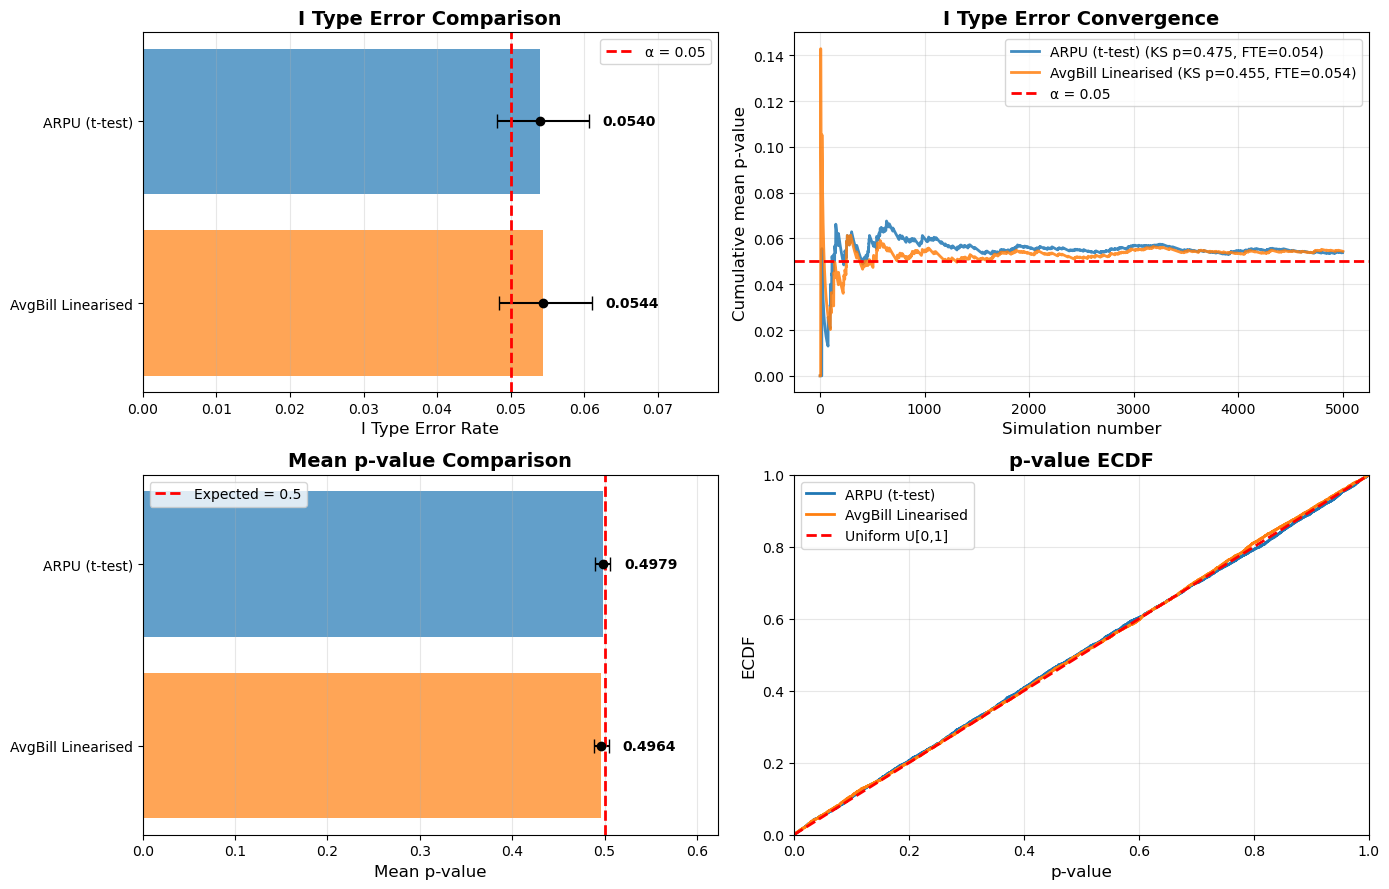

✅  ARPU (t-test)         FTE=0.054  CI=[0.048, 0.061]
✅  AvgBill Linearised    FTE=0.054  CI=[0.048, 0.061]


In [12]:
aa_pvalues2, aa_stats2 = bm2.aa_benchmark(
    n_sims=5_000,
    plot_hists=True,
    n_jobs=-1,
    verbose=False,
)

# Build shortlist for Part 2
shortlist2, labels2 = [], []
for designer, name, s in zip(bm2.designers, bm2.labels, aa_stats2):
    passes = s['mean_p_ft_left'] <= bm2.alpha
    tag    = "✅" if passes else "❌"
    print(f"{tag}  {name:<20}  FTE={s['mean_p_ft']:.3f}  CI=[{s['mean_p_ft_left']:.3f}, {s['mean_p_ft_right']:.3f}]")
    if passes:
        shortlist2.append(designer)
        labels2.append(name)


## Step 2: Power Comparison

A 5 % effect on the metric is injected into each designer.  
Note that the **effect is applied differently** per designer type:  
  
- `DesignerIid` multiplies raw values by 1.05
- `DesignerRatioLin` applies the 5 % effect to the **revenue numerator** — the correct way to model a lift in average bill

This ensures a like-for-like sensitivity comparison.


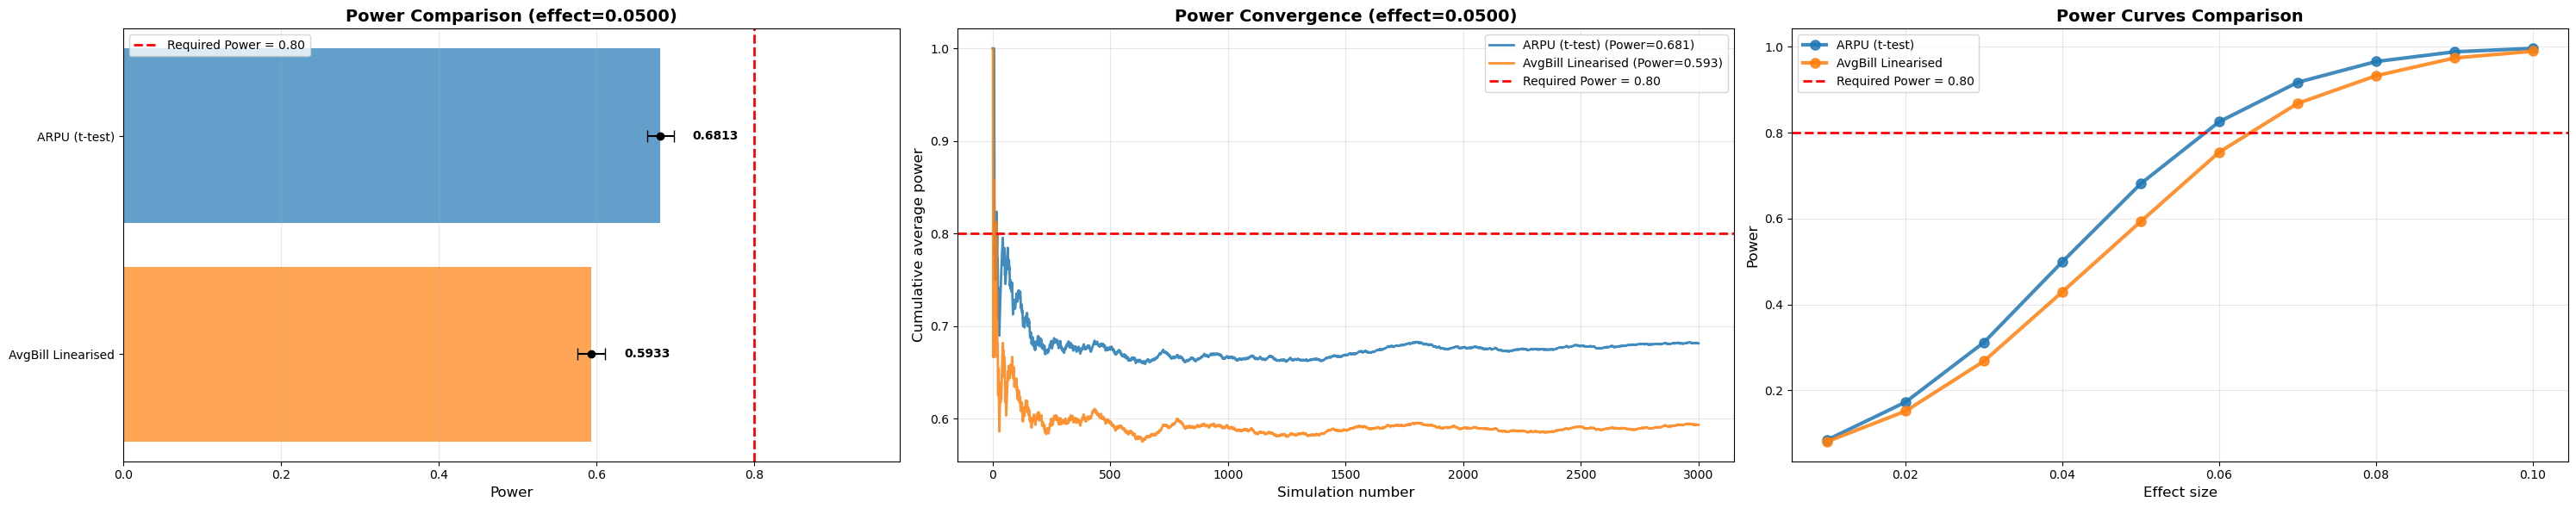

In [11]:
bm2_short = BenchMarker(shortlist2, alpha=0.05, beta=0.20)

bar_stats2, power_curves2 = bm2_short.ab_benchmark(
    bar_effect=0.05,
    power_curve_effects=list(np.linspace(0.01, 0.10, 10)),
    n_sims=3_000,
    n_jobs=-1,
    verbose=False
)

## The Decision Checklist

Use this four-step workflow every time you need to pick the best experiment setup from a list of candidates.  
  
---  
  
### ✅ Step 0 — Quick Variance Sanity Check  
  
```python
bm.compare_variance()
```
  
_Purpose:_ get a fast, formula-based ranking of effective metric variance across designers.  
_Outcome:_ rough orientation — does not replace simulation.  
  
---  
  
### ✅ Step 1 (Gate) — Type I Error Check  

```python
aa_pvalues, aa_stats = bm.aa_benchmark(n_sims=5_000, plot_hists=True)
```
  
_Purpose:_ verify every designer produces a calibrated test under the null.  
_Pass criterion:_ CI lower bound for FTE ≤ α.  
_Action:_ eliminate all failing designers — they cannot be trusted in production regardless of their apparent power.  
  
---  
  
### ✅ Step 2 — Power Race
  
```python
bar_stats, curves = bm_short.ab_benchmark(
    bar_effect=TARGET_EFFECT,
    power_curve_effects=np.linspace(0.01, 0.10, 10),
    n_sims=3_000,
)
```
  
_Purpose:_ compare power of surviving designers at the same injected effect.
  
_Action:_ choose the designer with the highest power across the target effect range.  
  
---  
  
### ☑️ Step 3 (Optional) — Directional Agreement  
  
```python
bm.directional_analysis(designer1=d_baseline, designer2=d_winner, effect=0.05)
```
  
_Purpose:_ confirm the winner agrees with the baseline on effect direction.  
_Aim:_ sign agreement ≥ 0.95, R² ≥ 0.90.  
_When to use:_ deploying a new or untested method for the first time.  

## Summary

| Lesson | Takeaway |
|---|---|
| Type I error gate | A method that inflates FTE must be excluded — no level of power justifies miscalibration |
| Fair power comparison | Use **the same injected effect** for all surviving candidates |
| Variance reduction | CUPED / PostStratification deliver real power gains at no FTE cost when a strong covariate is available |
| Ratio metrics | Always use `DesignerRatioLin` (linearisation) for ratio metrics — the naive per-user ratio targets a different estimand and loses calibration at small *N* |
| `BenchMarker` workflow | `compare_variance` → `aa_benchmark` (gate) → `ab_benchmark` (power race) → `directional_analysis` (sanity check) |

The `BenchMarker` class automates all of this under identical simulation conditions, making the comparison both efficient and reproducible.